# Assignment 1 — User Authentication using Biometric Features

**Data.** `biomet_data.csv` — 100 users × 10 samples × 144 features.
Samples 1–5 are the enrollment session, samples 6–10 were captured 6 months later.

**Protocol.** The 5 enrollment samples of each user form that user's *gallery* (templates);
the 5 later samples are the *probes* (test set). Every probe is matched against every
enrolled template of every user.

**Computed here, for both Euclidean distance and cosine similarity:**

| | Deliverable |
|---|---|
| A | Genuine distribution |
| B | Imposter distribution |
| C | FAR plot |
| D | FRR plot |
| E | Receiver Operating Characteristic |
| F | Equal Error Rate and Decidability index |

Run the cells top to bottom. Figures are shown inline **and** written to `results/`.

## 0. Setup — imports, constants and plot style

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

%matplotlib inline

DATA_FILE  = "biomet_data.csv"
OUT_DIR    = "results"
N_USERS    = 100
N_SAMPLES  = 10     # samples per user
N_TRAIN    = 5      # first 5 = enrollment (gallery); last 5 = test probes
N_FEATURES = 144

os.makedirs(OUT_DIR, exist_ok=True)

# ---- figure design tokens -------------------------------------------------
# Colours come from a colour-blind-safe categorical palette (blue / orange);
# the pair was checked for CVD separation, so genuine vs imposter and
# FAR vs FRR stay distinguishable for deuteranopic and tritanopic readers.
SURFACE, INK, INK_2 = "#fcfcfb", "#0b0b0b", "#52514e"
MUTED, GRID, AXIS   = "#898781", "#e1e0d9", "#c3c2b7"
C_GENUINE = C_EUC = C_FRR = "#2a78d6"   # blue
C_IMPOSTER = C_COS = C_FAR = "#eb6834"  # orange

plt.rcParams.update({
    "font.family": ["Segoe UI", "DejaVu Sans", "sans-serif"], "font.size": 9,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.labelcolor": INK_2,
    "axes.titlecolor": INK, "axes.titlesize": 10, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.titlepad": 8,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.7,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 2.0, "figure.dpi": 120,
})

def style(ax):
    """Recessive chrome: no top/right spines, hairline grid only."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return ax

## 1. Loading the data and recovering the train / test split

The file holds **one feature per row and one sample per column** — 144 rows × 1000
whitespace-separated columns. Transposing gives the usual *(sample × feature)* design matrix.

Column order is **user-major**: columns 0–9 are user 1's ten samples, 10–19 are user 2's, etc.
The next cell verifies that layout instead of assuming it.

In [2]:
raw = np.loadtxt(DATA_FILE)
print("file shape (features x samples):", raw.shape)

data = raw.T.reshape(N_USERS, N_SAMPLES, N_FEATURES)   # (user, sample, feature)
print("reshaped to (users, samples, features):", data.shape)

file shape (features x samples): (144, 1000)
reshaped to (users, samples, features): (100, 10, 144)


In [3]:
# ---- sanity check: is the column order really user-major? -----------------
D  = raw.T
Dn = D / np.linalg.norm(D, axis=1, keepdims=True)
S  = Dn @ Dn.T

def within_vs_between(labels):
    same = labels[:, None] == labels[None, :]
    return S[same].mean(), S[~same].mean()

user_major  = np.repeat(np.arange(N_USERS), N_SAMPLES)   # u1s1..u1s10, u2s1..
sample_major = np.tile(np.arange(N_USERS), N_SAMPLES)    # u1s1..u100s1, u1s2..

print("hypothesis            within-class   between-class")
print("user-major   : %12.4f %13.4f" % within_vs_between(user_major))
print("sample-major : %12.4f %13.4f" % within_vs_between(sample_major))

# ---- and are samples 0-4 really a different session from 5-9? -------------
w_enroll, w_test, cross = [], [], []
for u in range(N_USERS):
    for a in range(N_SAMPLES):
        for b in range(a + 1, N_SAMPLES):
            s = S[u * N_SAMPLES + a, u * N_SAMPLES + b]
            (w_enroll if b < N_TRAIN else w_test if a >= N_TRAIN else cross).append(s)

print("\nmean cosine similarity inside a user")
print("  enrollment session (samples 1-5) : %.5f" % np.mean(w_enroll))
print("  test session       (samples 6-10): %.5f" % np.mean(w_test))
print("  across the two sessions          : %.5f" % np.mean(cross))

hypothesis            within-class   between-class
user-major   :       0.9886        0.9565
sample-major :       0.9607        0.9568

mean cosine similarity inside a user
  enrollment session (samples 1-5) : 0.98997
  test session       (samples 6-10): 0.98905
  across the two sessions          : 0.98556


Both checks pass: within-user similarity is far above between-user similarity **only** under the
user-major reading, and similarity *within* a session beats similarity *across* the two sessions —
exactly the template-ageing effect that a 6-month gap should produce. The split
`data[:, :5]` = gallery, `data[:, 5:]` = probes is therefore the one the assignment describes.

## 2. The two matching criteria

$$d_{\text{euc}}(x,y)=\lVert x-y\rVert_2 \qquad\qquad
  s_{\cos}(x,y)=\frac{x\cdot y}{\lVert x\rVert\,\lVert y\rVert}$$

Euclidean is a **distance** (small = same person); cosine is a **similarity**
(large = same person). Every downstream function therefore carries a
`higher_is_better` flag so the accept rule flips correctly.

In [4]:
def euclidean_matrix(probes, gallery):
    """Pairwise Euclidean DISTANCE, |probes| x |gallery|.  Lower = better match."""
    d2 = (np.sum(probes ** 2, axis=1)[:, None]
          + np.sum(gallery ** 2, axis=1)[None, :]
          - 2.0 * probes @ gallery.T)
    return np.sqrt(np.maximum(d2, 0.0))          # clamp tiny negatives from round-off


def cosine_matrix(probes, gallery):
    """Pairwise cosine SIMILARITY, |probes| x |gallery|.  Higher = better match."""
    p = probes  / np.linalg.norm(probes,  axis=1, keepdims=True)
    g = gallery / np.linalg.norm(gallery, axis=1, keepdims=True)
    return np.clip(p @ g.T, -1.0, 1.0)


MATCHERS = {                       # name: (function, higher_is_better)
    "Euclidean distance": (euclidean_matrix, False),
    "Cosine similarity":  (cosine_matrix,    True),
}

## 3. Generating the genuine and imposter score sets

Each of the 500 probes is compared with each of the 500 enrolled templates → a 500 × 500
score matrix. A comparison is **genuine** when probe and template belong to the same user and
**imposter** otherwise.

Two fusion rules are evaluated:

* **`all-pairs`** *(primary — used for every figure)* — one score per *(probe, template)* pair.
  Genuine = 100 × 5 × 5 = **2 500**; imposter = 100 × 5 × 99 × 5 = **247 500**.
* **`best-of-5`** — the 5 template scores of a user are fused by *min distance* /
  *max similarity*, giving one score per *(probe, user)* claim, which is how a deployed
  system with 5 stored templates would actually decide.
  Genuine = **500**; imposter = **49 500**.

In [5]:
def score_sets(data, matcher, higher_is_better, fusion="all-pairs"):
    gallery = data[:, :N_TRAIN, :].reshape(-1, N_FEATURES)    # 500 x 144 (enrollment)
    probes  = data[:, N_TRAIN:, :].reshape(-1, N_FEATURES)    # 500 x 144 (test)

    S = matcher(probes, gallery)                              # 500 x 500
    probe_user = np.repeat(np.arange(N_USERS), N_SAMPLES - N_TRAIN)
    gal_user   = np.repeat(np.arange(N_USERS), N_TRAIN)

    if fusion == "best-of-5":
        S = S.reshape(len(probes), N_USERS, N_TRAIN)
        S = S.max(axis=2) if higher_is_better else S.min(axis=2)
        gal_user = np.arange(N_USERS)

    genuine = probe_user[:, None] == gal_user[None, :]
    return S[genuine].ravel(), S[~genuine].ravel()


for name, (fn, hib) in MATCHERS.items():
    g, i = score_sets(data, fn, hib)
    print(f"{name:<20} genuine {g.size:>7,}   imposter {i.size:>8,}   "
          f"gen mean {g.mean():.5f}   imp mean {i.mean():.5f}")

Euclidean distance   genuine   2,500   imposter  247,500   gen mean 346.85815   imp mean 732.04788
Cosine similarity    genuine   2,500   imposter  247,500   gen mean 0.98556   imp mean 0.95652


## 4. FAR, FRR, ROC, EER and the decidability index

**Decision rule.** Similarity: accept iff `score >= threshold`. Distance: accept iff `score <= threshold`.

$$\mathrm{FAR}(t)=\frac{\#\{\text{imposter scores accepted at }t\}}{\#\text{imposter}}
\qquad
\mathrm{FRR}(t)=\frac{\#\{\text{genuine scores rejected at }t\}}{\#\text{genuine}}$$

Rates are computed **exactly at every distinct score in the data** (via `searchsorted` on the
sorted score arrays) — no histogram binning, so the EER is not quantised by a bin width.

**EER** is the rate where FAR(t) = FRR(t), found by linearly interpolating the sign change of
FAR − FRR. **Decidability index**

$$d' = \frac{\lvert \mu_{\text{gen}} - \mu_{\text{imp}} \rvert}{\sqrt{\tfrac{1}{2}\left(\sigma_{\text{gen}}^2+\sigma_{\text{imp}}^2\right)}}$$

measures how many pooled standard deviations separate the two distributions — higher is better,
and unlike the EER it is threshold-free.

In [6]:
def error_rates(genuine, imposter, higher_is_better):
    """Exact FAR/FRR at every distinct score (plus one padding point at each end)."""
    g, i = np.sort(genuine), np.sort(imposter)
    t = np.unique(np.concatenate([g, i]))
    span = t[-1] - t[0]
    t = np.concatenate([[t[0] - 0.01 * span], t, [t[-1] + 0.01 * span]])

    if higher_is_better:                                   # accept iff score >= t
        far = 1.0 - np.searchsorted(i, t, side="left")  / i.size    # P(imp >= t)
        frr =       np.searchsorted(g, t, side="left")  / g.size    # P(gen <  t)
    else:                                                  # accept iff score <= t
        far =       np.searchsorted(i, t, side="right") / i.size    # P(imp <= t)
        frr = 1.0 - np.searchsorted(g, t, side="right") / g.size    # P(gen >  t)
    return t, far, frr


def equal_error_rate(t, far, frr):
    """EER by linear interpolation of the FAR - FRR sign change."""
    d = far - frr
    k = int(np.argmin(np.abs(d)))
    crossings = np.where(np.sign(d[:-1]) * np.sign(d[1:]) < 0)[0]
    if crossings.size:
        j = crossings[np.argmin(np.abs(crossings - k))]
        w = d[j] / (d[j] - d[j + 1])
        return float(far[j] + w * (far[j + 1] - far[j])), float(t[j] + w * (t[j + 1] - t[j]))
    return float(0.5 * (far[k] + frr[k])), float(t[k])


def decidability(genuine, imposter):
    """d' = |mu_g - mu_i| / sqrt((var_g + var_i) / 2)."""
    return float(abs(genuine.mean() - imposter.mean())
                 / np.sqrt(0.5 * (genuine.var(ddof=1) + imposter.var(ddof=1))))


def roc(far, frr):
    """ROC as (FAR, GAR) sorted by FAR, with AUC by the trapezoid rule."""
    gar = 1.0 - frr
    o = np.argsort(far, kind="stable")
    x, y = far[o], gar[o]
    auc = np.trapezoid(y, x) if hasattr(np, "trapezoid") else np.trapz(y, x)
    return x, y, float(auc)


def evaluate(genuine, imposter, higher_is_better):
    t, far, frr = error_rates(genuine, imposter, higher_is_better)
    eer, eer_thr = equal_error_rate(t, far, frr)
    x, y, auc = roc(far, frr)
    return {"genuine": genuine, "imposter": imposter,
            "thresholds": t, "far": far, "frr": frr,
            "roc_far": x, "roc_gar": y, "auc": auc,
            "eer": eer, "eer_threshold": eer_thr,
            "dprime": decidability(genuine, imposter),
            "gar_at_far_1pct":   float(np.interp(0.01,  x, y)),
            "gar_at_far_0.1pct": float(np.interp(0.001, x, y))}

## 5. Running every configuration

Besides the two matchers and the two fusion rules, the raw features are compared against a
**z-scored** copy (per-feature standardisation fitted on the *enrollment* data only, so no test
information leaks into the scaling). That extra axis is not required by the assignment — it is
included because it explains *why* the two matchers differ, see the discussion at the end.

In [7]:
# z-scored copy: mean/std fitted on enrollment samples only
train_flat = data[:, :N_TRAIN, :].reshape(-1, N_FEATURES)
data_z = (data - train_flat.mean(0)) / train_flat.std(0, ddof=1)

feature_sets = {"raw": data, "z-scored": data_z}
rows, primary = [], {}

for feat_name, X in feature_sets.items():
    for proto in ("all-pairs", "best-of-5"):
        for m_name, (fn, hib) in MATCHERS.items():
            g, i = score_sets(X, fn, hib, fusion=proto)
            res = evaluate(g, i, hib)
            rows.append({"features": feat_name, "protocol": proto, "matcher": m_name,
                         "n_genuine": g.size, "n_imposter": i.size,
                         "gen_mean": g.mean(), "gen_std": g.std(ddof=1),
                         "imp_mean": i.mean(), "imp_std": i.std(ddof=1),
                         "eer": res["eer"], "eer_threshold": res["eer_threshold"],
                         "dprime": res["dprime"], "auc": res["auc"],
                         "gar_at_far_1pct": res["gar_at_far_1pct"],
                         "gar_at_far_0.1pct": res["gar_at_far_0.1pct"]})
            if feat_name == "raw" and proto == "all-pairs":
                primary[m_name] = res          # <- what every figure below plots

print("configurations evaluated:", len(rows))

configurations evaluated: 8


## A + B. Genuine and imposter distributions

Both distributions are drawn on one axis, as probability **densities** — the imposter set is
100× larger than the genuine set, so raw counts would be unreadable. The dashed line marks the
EER operating threshold; the overlap to either side of it *is* the error the system makes.

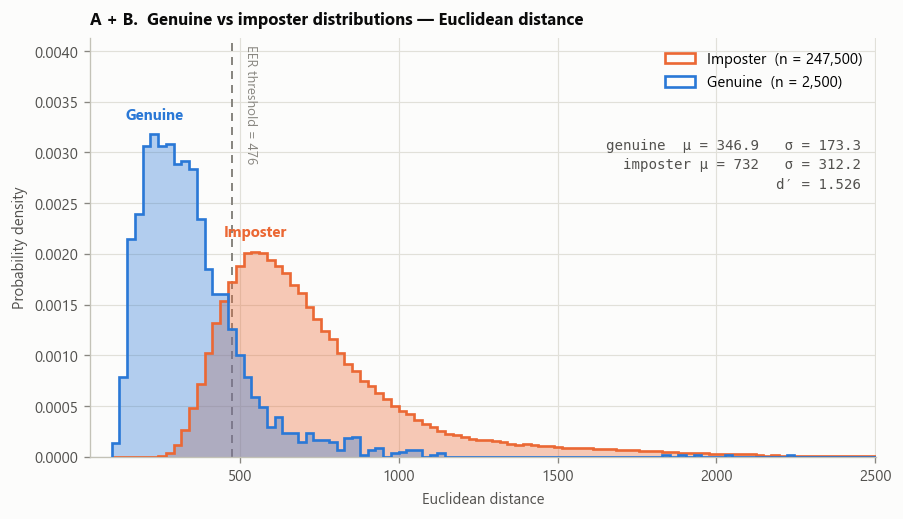

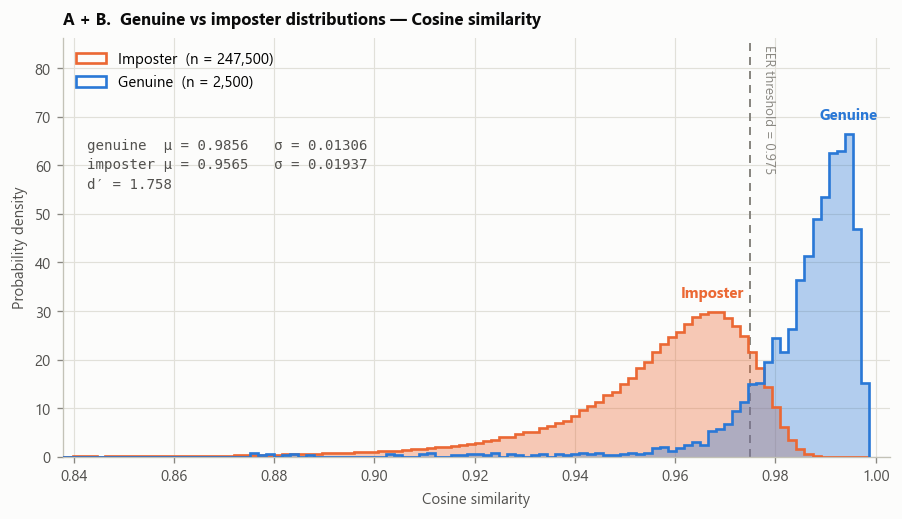

In [8]:
def fig_distributions(res, name, xlabel, fname):
    g, i = res["genuine"], res["imposter"]
    fig, ax = plt.subplots(figsize=(7.6, 4.4)); style(ax)

    bins = np.linspace(min(g.min(), i.min()), max(g.max(), i.max()), 120)
    hists = {}
    for vals, colour, label in ((i, C_IMPOSTER, "Imposter"), (g, C_GENUINE, "Genuine")):
        ax.hist(vals, bins=bins, density=True, color=colour, alpha=0.35, zorder=2)
        ax.hist(vals, bins=bins, density=True, histtype="step", color=colour,
                linewidth=1.6, zorder=3, label=f"{label}  (n = {vals.size:,})")
        hists[label] = np.histogram(vals, bins=bins, density=True)[0]

    # crop the long low-density tail so the informative region fills the panel
    x_lo = min(np.percentile(g, 0.05), np.percentile(i, 0.05))
    x_hi = max(np.percentile(g, 99.9), np.percentile(i, 99.9))
    pad = 0.03 * (x_hi - x_lo)
    ax.set_xlim(x_lo - pad, x_hi + pad)
    ax.set_ylim(0, max(h.max() for h in hists.values()) * 1.30)   # headroom for labels

    centres = 0.5 * (bins[:-1] + bins[1:])
    for label, colour in (("Imposter", C_IMPOSTER), ("Genuine", C_GENUINE)):
        k = int(np.argmax(hists[label]))                  # direct label at each mode,
        ax.annotate(label, xy=(centres[k], hists[label][k]),   # so identity is never
                    xytext=(0, 9), textcoords="offset points", # colour-alone
                    ha="center", color=colour, fontsize=9, fontweight="bold", zorder=4)

    ax.axvline(res["eer_threshold"], color=MUTED, linewidth=1.2, linestyle=(0, (4, 3)), zorder=1)
    ax.annotate(f"EER threshold = {res['eer_threshold']:.4g}",           # in the headroom,
                xy=(res["eer_threshold"], ax.get_ylim()[1]),             # clear of the bars
                xytext=(7, -4), textcoords="offset points", color=MUTED, fontsize=8,
                ha="left", va="top", rotation=270)

    ax.set_title(f"A + B.  Genuine vs imposter distributions — {name}")
    ax.set_xlabel(xlabel); ax.set_ylabel("Probability density")

    # park legend + stats in whichever half of the panel carries less mass
    mid = 0.5 * sum(ax.get_xlim())
    left  = max(h[centres <  mid].max(initial=0) for h in hists.values())
    right = max(h[centres >= mid].max(initial=0) for h in hists.values())
    side = "left" if left < right else "right"
    ax.legend(loc=f"upper {side}")
    ax.text(0.03 if side == "left" else 0.98, 0.76,
            f"genuine  \u03bc = {g.mean():.4g}   \u03c3 = {g.std(ddof=1):.4g}\n"
            f"imposter \u03bc = {i.mean():.4g}   \u03c3 = {i.std(ddof=1):.4g}\n"
            f"d\u2032 = {res['dprime']:.3f}",
            transform=ax.transAxes, ha=side, va="top", fontsize=8.5,
            color=INK_2, linespacing=1.5, family="monospace")

    fig.tight_layout(); fig.savefig(os.path.join(OUT_DIR, fname), bbox_inches="tight")
    plt.show()


fig_distributions(primary["Euclidean distance"], "Euclidean distance",
                  "Euclidean distance", "fig1_distributions_euclidean.png")
fig_distributions(primary["Cosine similarity"], "Cosine similarity",
                  "Cosine similarity", "fig2_distributions_cosine.png")

## C + D. FAR and FRR against the threshold

FAR rises and FRR falls as the threshold is relaxed — the classic trade-off. The third panel
overlays them and marks the crossing, which is the EER.

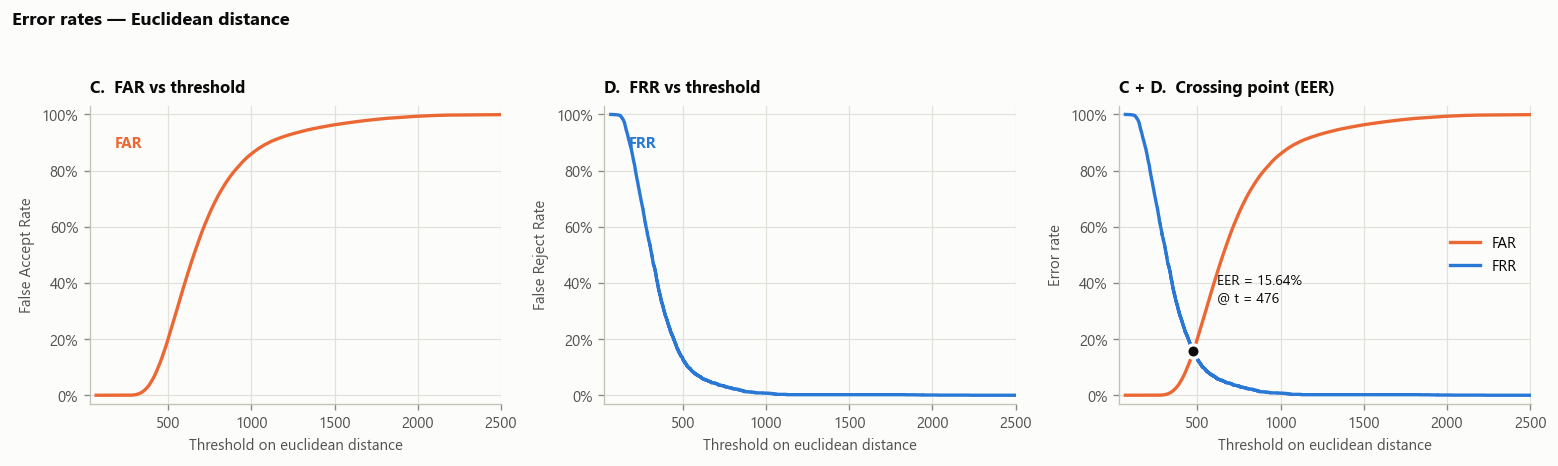

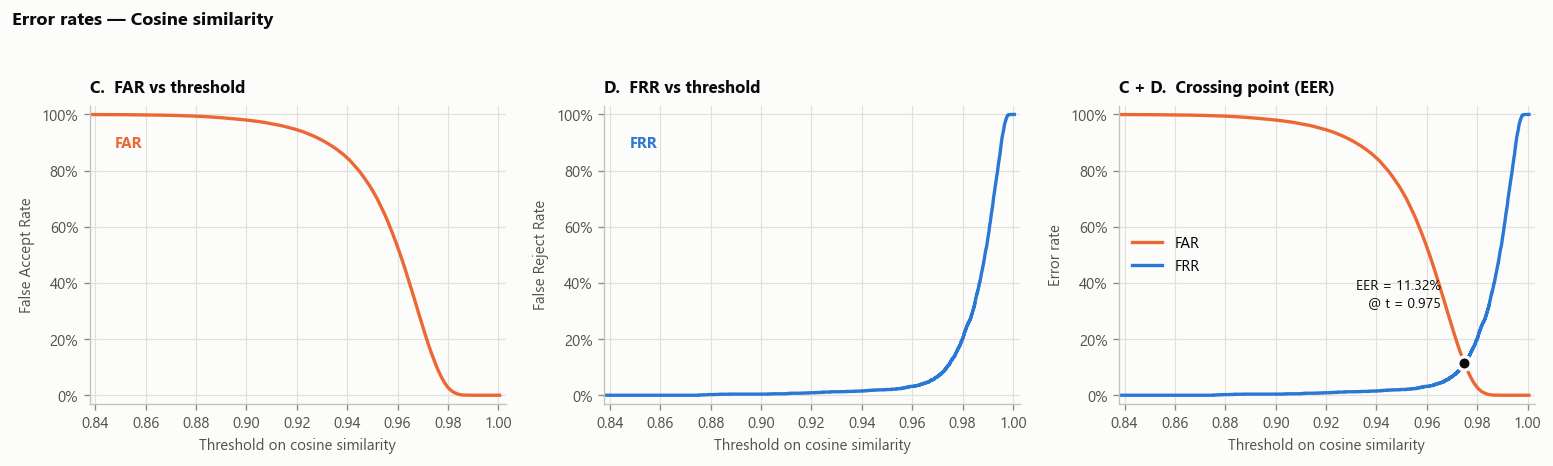

In [9]:
def fig_far_frr(res, name, xlabel, fname):
    t, far, frr = res["thresholds"], res["far"], res["frr"]
    g, i = res["genuine"], res["imposter"]
    x_lo = min(np.percentile(g, 0.05), np.percentile(i, 0.05))
    x_hi = max(np.percentile(g, 99.9), np.percentile(i, 99.9))
    pad = 0.03 * (x_hi - x_lo)

    fig, axes = plt.subplots(1, 3, figsize=(13.0, 3.9))
    for ax in axes:
        style(ax)
        ax.set_xlabel(f"Threshold on {xlabel.lower()}")
        ax.set_xlim(x_lo - pad, x_hi + pad); ax.set_ylim(-0.03, 1.03)
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))

    axes[0].plot(t, far, color=C_FAR)
    axes[0].set_title("C.  FAR vs threshold"); axes[0].set_ylabel("False Accept Rate")
    axes[0].annotate("FAR", xy=(0.06, 0.86), xycoords="axes fraction",
                     color=C_FAR, fontweight="bold")

    axes[1].plot(t, frr, color=C_FRR)
    axes[1].set_title("D.  FRR vs threshold"); axes[1].set_ylabel("False Reject Rate")
    axes[1].annotate("FRR", xy=(0.06, 0.86), xycoords="axes fraction",
                     color=C_FRR, fontweight="bold")

    axes[2].plot(t, far, color=C_FAR, label="FAR")
    axes[2].plot(t, frr, color=C_FRR, label="FRR")
    axes[2].plot([res["eer_threshold"]], [res["eer"]], marker="o", markersize=8, color=INK,
                 markeredgecolor=SURFACE, markeredgewidth=2, zorder=5)
    # keep the callout and the legend on whichever side of the crossing is empty
    on_right = res["eer_threshold"] > 0.5 * (x_lo + x_hi)
    axes[2].annotate(f"EER = {res['eer'] * 100:.2f}%\n@ t = {res['eer_threshold']:.4g}",
                     xy=(res["eer_threshold"], res["eer"]),
                     xytext=(-14, 34) if on_right else (14, 30), textcoords="offset points",
                     ha="right" if on_right else "left",
                     fontsize=8.5, color=INK, linespacing=1.4)
    axes[2].set_title("C + D.  Crossing point (EER)"); axes[2].set_ylabel("Error rate")
    axes[2].legend(loc="center left" if on_right else "center right")

    fig.suptitle(f"Error rates — {name}", x=0.006, ha="left",
                 fontsize=11, fontweight="bold", color=INK)
    fig.tight_layout(rect=(0, 0, 1, 0.94))
    fig.savefig(os.path.join(OUT_DIR, fname), bbox_inches="tight")
    plt.show()


fig_far_frr(primary["Euclidean distance"], "Euclidean distance",
            "Euclidean distance", "fig3_far_frr_euclidean.png")
fig_far_frr(primary["Cosine similarity"], "Cosine similarity",
            "Cosine similarity", "fig4_far_frr_cosine.png")

## E. Receiver Operating Characteristic

GAR = 1 − FRR plotted against FAR, both matchers on one axis so they can be compared directly.
The right panel uses a log FAR axis, because the operating region a real system cares about
(FAR ≤ 1 %) is compressed into the leftmost pixels of the linear plot.

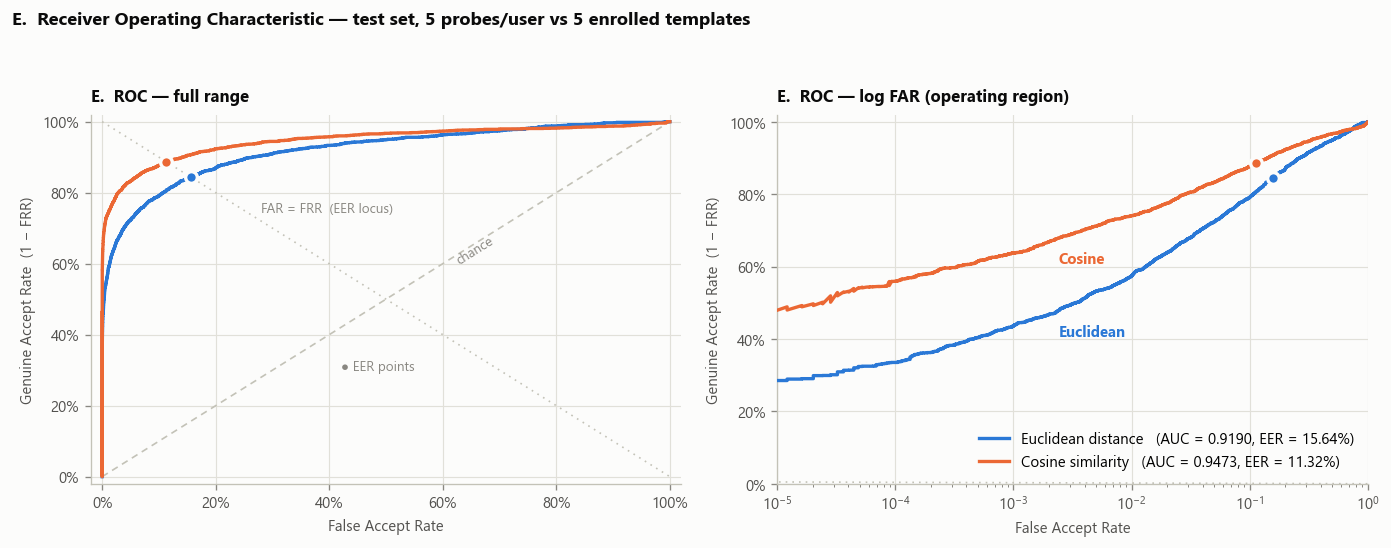

In [10]:
def fig_roc(results, fname):
    fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.6))
    for ax in axes:
        style(ax)
        ax.set_xlabel("False Accept Rate")
        ax.set_ylabel("Genuine Accept Rate  (1 \u2212 FRR)")
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))

    colours = {"Euclidean distance": C_EUC, "Cosine similarity": C_COS}
    for name, res in results.items():
        c = colours[name]
        lab = f"{name}   (AUC = {res['auc']:.4f}, EER = {res['eer']*100:.2f}%)"
        for ax in axes:
            ax.plot(res["roc_far"], res["roc_gar"], color=c, label=lab, zorder=3)
            ax.plot([res["eer"]], [1 - res["eer"]], marker="o", markersize=7, color=c,
                    markeredgecolor=SURFACE, markeredgewidth=2, zorder=4)

    axes[0].plot([0, 1], [0, 1], color=AXIS, linewidth=1.0, linestyle=(0, (4, 3)), zorder=1)
    axes[0].annotate("chance", xy=(0.62, 0.60), color=MUTED, fontsize=8, rotation=32)
    for ax in axes:
        ax.plot([0, 1], [1, 0], color=AXIS, linewidth=1.0, linestyle=(0, (1, 3)), zorder=1)
    axes[0].annotate("FAR = FRR  (EER locus)", xy=(0.28, 0.745), color=MUTED, fontsize=8)
    axes[0].annotate("\u25cf EER points", xy=(0.42, 0.30), color=MUTED, fontsize=8)

    axes[0].set_xlim(-0.02, 1.02); axes[0].set_ylim(-0.02, 1.02)
    axes[0].xaxis.set_major_formatter(PercentFormatter(xmax=1.0))
    axes[0].set_title("E.  ROC \u2014 full range")

    axes[1].set_xscale("log"); axes[1].set_xlim(1e-5, 1.0); axes[1].set_ylim(0.0, 1.02)
    axes[1].set_title("E.  ROC \u2014 log FAR (operating region)")
    axes[1].legend(loc="lower right")
    for name, res in results.items():                      # direct labels as well
        k = min(int(np.searchsorted(res["roc_far"], 2e-3)), res["roc_far"].size - 1)
        axes[1].annotate(name.split()[0], xy=(max(res["roc_far"][k], 1e-5), res["roc_gar"][k]),
                         xytext=(6, -13), textcoords="offset points",
                         color=colours[name], fontsize=9, fontweight="bold")

    fig.suptitle("E.  Receiver Operating Characteristic \u2014 test set, 5 probes/user vs 5 enrolled templates",
                 x=0.006, ha="left", fontsize=11, fontweight="bold", color=INK)
    fig.tight_layout(rect=(0, 0, 1, 0.93))
    fig.savefig(os.path.join(OUT_DIR, fname), bbox_inches="tight")
    plt.show()


fig_roc(primary, "fig5_roc.png")

### E (extra). DET curve

The same information as the ROC with both axes logarithmic. A DET curve spreads out the
low-error corner where the two matchers actually differ, so the gap between them is easier to read.

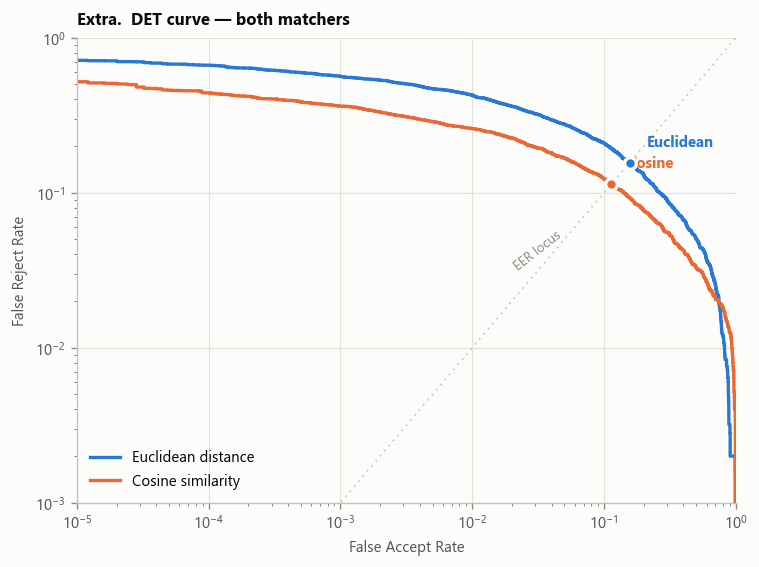

In [11]:
def fig_det(results, fname):
    fig, ax = plt.subplots(figsize=(6.4, 4.8)); style(ax)
    colours = {"Euclidean distance": C_EUC, "Cosine similarity": C_COS}
    for name, res in results.items():
        m = (res["far"] > 0) & (res["frr"] > 0)
        ax.plot(res["far"][m], res["frr"][m], color=colours[name], label=name)
        ax.plot([res["eer"]], [res["eer"]], marker="o", markersize=7, color=colours[name],
                markeredgecolor=SURFACE, markeredgewidth=2, zorder=4)
        ax.annotate(name.split()[0], xy=(res["eer"], res["eer"]), xytext=(10, 10),
                    textcoords="offset points", color=colours[name],
                    fontsize=9, fontweight="bold")
    ax.plot([1e-5, 1], [1e-5, 1], color=AXIS, linewidth=1.0, linestyle=(0, (1, 3)))
    ax.annotate("EER locus", xy=(2e-2, 3.2e-2), color=MUTED, fontsize=8, rotation=38)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(1e-5, 1); ax.set_ylim(1e-3, 1)
    ax.set_xlabel("False Accept Rate"); ax.set_ylabel("False Reject Rate")
    ax.set_title("Extra.  DET curve \u2014 both matchers")
    ax.legend(loc="lower left")
    fig.tight_layout(); fig.savefig(os.path.join(OUT_DIR, fname), bbox_inches="tight")
    plt.show()


fig_det(primary, "fig6_det.png")

## F. Equal Error Rate and Decidability index

The numbers below are the answer to part F. The table also carries AUC and two fixed operating
points (GAR at FAR = 1 % and 0.1 %), which say more about usable performance than the EER alone.

In [12]:
hdr = (f"{'features':<10}{'protocol':<12}{'matcher':<20}"
       f"{'EER %':>9}{'d-prime':>10}{'AUC':>10}{'GAR@FAR=1%':>13}{'GAR@FAR=0.1%':>15}")
lines = ["Biometric verification performance summary", "=" * len(hdr), hdr, "-" * len(hdr)]
for r in rows:
    lines.append(f"{r['features']:<10}{r['protocol']:<12}{r['matcher']:<20}"
                 f"{r['eer']*100:>9.3f}{r['dprime']:>10.3f}{r['auc']:>10.5f}"
                 f"{r['gar_at_far_1pct']*100:>12.2f}%{r['gar_at_far_0.1pct']*100:>14.2f}%")
lines += ["-" * len(hdr), "",
          "Score statistics (primary protocol: raw features, all-pairs)", "-" * len(hdr)]
for r in rows:
    if r["features"] != "raw" or r["protocol"] != "all-pairs":
        continue
    lines.append(f"{r['matcher']:<20} genuine  n={r['n_genuine']:>7,}  "
                 f"mean={r['gen_mean']:>10.5f}  std={r['gen_std']:>10.5f}")
    lines.append(f"{'':<20} imposter n={r['n_imposter']:>7,}  "
                 f"mean={r['imp_mean']:>10.5f}  std={r['imp_std']:>10.5f}")
    lines.append(f"{'':<20} EER = {r['eer']*100:.3f}% at threshold "
                 f"{r['eer_threshold']:.6g};  d' = {r['dprime']:.3f}")

summary = "\n".join(lines)
print(summary)

with open(os.path.join(OUT_DIR, "metrics_summary.txt"), "w") as fh:
    fh.write(summary + "\n")

cols = list(rows[0].keys())
with open(os.path.join(OUT_DIR, "metrics_summary.csv"), "w", newline="") as fh:
    fh.write(",".join(cols) + "\n")
    for r in rows:
        fh.write(",".join(f"{r[c]:.6g}" if isinstance(r[c], float) else str(r[c])
                          for c in cols) + "\n")
print("\nwrote results/metrics_summary.txt and results/metrics_summary.csv")

Biometric verification performance summary
features  protocol    matcher                 EER %   d-prime       AUC   GAR@FAR=1%   GAR@FAR=0.1%
---------------------------------------------------------------------------------------------------
raw       all-pairs   Euclidean distance     15.640     1.526   0.91903       57.40%         43.60%
raw       all-pairs   Cosine similarity      11.320     1.758   0.94730       74.08%         63.76%
raw       best-of-5   Euclidean distance      9.400     1.838   0.96259       74.40%         63.40%
raw       best-of-5   Cosine similarity       5.600     2.025   0.97826       89.80%         84.40%
z-scored  all-pairs   Euclidean distance     15.840     1.533   0.91850       57.32%         43.68%
z-scored  all-pairs   Cosine similarity      11.633     2.425   0.95078       52.28%         28.90%
z-scored  best-of-5   Euclidean distance      9.200     1.858   0.96247       73.80%         63.00%
z-scored  best-of-5   Cosine similarity       7.566     2

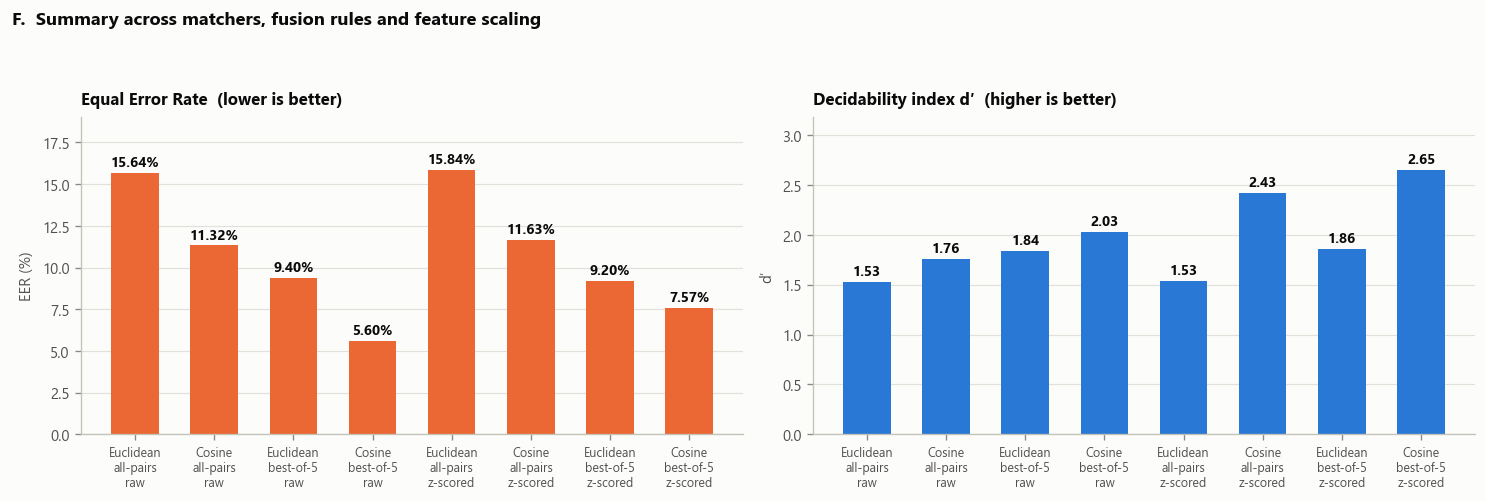

In [13]:
def fig_summary_bars(rows, fname):
    short = {"Euclidean distance": "Euclidean", "Cosine similarity": "Cosine"}
    labels = [f"{short[r['matcher']]}\n{r['protocol']}\n{r['features']}" for r in rows]
    x = np.arange(len(rows))

    fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.2))
    for ax, vals, title, ylab, colour, fmt in (
            (axes[0], [r["eer"] * 100 for r in rows],
             "Equal Error Rate  (lower is better)", "EER (%)", C_IMPOSTER, "{:.2f}%"),
            (axes[1], [r["dprime"] for r in rows],
             "Decidability index d\u2032  (higher is better)", "d\u2032", C_GENUINE, "{:.2f}")):
        style(ax)
        ax.bar(x, vals, width=0.6, color=colour, zorder=2)
        ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=7.5)
        ax.set_ylabel(ylab); ax.set_title(title)
        ax.grid(axis="x", visible=False)
        ax.set_ylim(0, max(vals) * 1.20)
        for xi, v in zip(x, vals):
            ax.annotate(fmt.format(v), xy=(xi, v), xytext=(0, 4), textcoords="offset points",
                        ha="center", fontsize=8.5, color=INK, fontweight="bold")

    fig.suptitle("F.  Summary across matchers, fusion rules and feature scaling",
                 x=0.006, ha="left", fontsize=11, fontweight="bold", color=INK)
    fig.tight_layout(rect=(0, 0, 1, 0.92))
    fig.savefig(os.path.join(OUT_DIR, fname), bbox_inches="tight")
    plt.show()


fig_summary_bars(rows, "fig7_summary.png")

## Which matching criterion performs best?

**Cosine similarity**, on every measure computed here.

| Primary protocol (raw features, all-pairs) | Euclidean | Cosine |
|---|---|---|
| EER | 15.64 % | **11.32 %** |
| Decidability d′ | 1.53 | **1.76** |
| AUC | 0.9190 | **0.9473** |
| GAR @ FAR = 1 % | 57.4 % | **74.1 %** |
| GAR @ FAR = 0.1 % | 43.6 % | **63.8 %** |

The margin holds under the more realistic `best-of-5` fusion too (5.60 % vs 9.40 % EER), and the
cosine ROC dominates the Euclidean one across the whole FAR range — it is not an artefact of one
operating point.

**Why cosine wins.** The 144 features are unnormalised magnitudes spanning roughly 16 to 682.
Euclidean distance is dominated by that overall scale, and overall scale is exactly what drifts
between the enrollment session and the session 6 months later (illumination, sensor gain, scaling
of the acquired image). Two samples of the same user taken 6 months apart can differ mostly in
magnitude while keeping the same *pattern* across features. Cosine similarity divides the
magnitude out and compares only the direction of the feature vector, so it discards the
session-dependent nuisance factor and keeps the identity-bearing information.

The z-scored rows in the table support that reading: standardising the features lifts cosine's
d′ from 1.76 to 2.43, yet its low-FAR performance gets *worse* (GAR @ FAR = 1 % falls from 74 % to
52 %). That divergence is a useful caution about d′ — it is a two-moment summary that is only a
faithful ranking statistic for roughly Gaussian scores, and these score distributions are visibly
skewed with heavy tails. **EER, ROC and the fixed operating points are the trustworthy comparison;
d′ is reported because the assignment asks for it, not because it should settle the question.**

**Caveats worth stating.** With 2 500 genuine scores the standard error on an 11 % EER is about
±0.6 %, so the 4-point gap between the matchers is comfortably real, while the difference between
the raw and z-scored variants of the *same* matcher is not always. FAR is estimated from 247 500
imposter scores, so the low-FAR end of the ROC is well determined down to about FAR = 10⁻⁴; below
that the curve is carried by a handful of scores and should not be over-read.